#### Case Study 1<br>
Phone Prices  

In [209]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [210]:
df=pd.read_csv('Mobile phone price.csv')

In [211]:
df.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($),Label
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999,1
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199,1
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899,1
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279,0
4,Google,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799,1


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Brand                   407 non-null    object
 1   Model                   407 non-null    object
 2   Storage                 407 non-null    object
 3   RAM                     407 non-null    object
 4   Screen Size (inches)    407 non-null    object
 5   Camera (MP)             407 non-null    object
 6   Battery Capacity (mAh)  407 non-null    int64 
 7   Price ($)               407 non-null    object
 8   Label                   407 non-null    int64 
dtypes: int64(2), object(7)
memory usage: 28.7+ KB


In [142]:
#checking statiscal describtion
df.describe()

,Battery Capacity (mAh),Label
count,407.000000,407.000000
mean,4676.476658,0.692875
std,797.193713,0.461870
min,1821.000000,0.000000
25%,4300.000000,0.000000
50%,5000.000000,1.000000
75%,5000.000000,1.000000
max,7000.000000,1.000000


In [143]:
df.isna().sum()#check if there are no values?

Brand                     0
Model                     0
Storage                   0
RAM                       0
Screen Size (inches)      0
Camera (MP)               0
Battery Capacity (mAh)    0
Price ($)                 0
Label                     0
dtype: int64

#### Data Cleaning

In [144]:
df.columns

Index(['Brand', 'Model', 'Storage ', 'RAM ', 'Screen Size (inches)',
       'Camera (MP)', 'Battery Capacity (mAh)', 'Price ($)', 'Label'],
      dtype='object')

In [145]:
df["Storage "] = df["Storage "].str.replace("GB","")#remove GB
df["Storage "] = df["Storage "].astype("float64")

In [146]:
df['RAM '] = df['RAM '].str.replace("GB","")#remove GB
df['RAM '] = df['RAM '].astype("float64")

In [147]:
df['Price ($)'].unique()

array(['999', '1199', '899', '279', '799', '249', '699', '329', '449',
       '199', '299', '379', '179', '729', '599', '139', '189', '399',
       '259', '159', '229', '499', '129', '529', '369', '1099', '169',
       '99', '459', '239', '1299', '429', '659', '269', '359', '$799 ',
       '$399 ', '$699 ', '$329 ', '$999 ', '$549 ', '$1,299 ', '$899 ',
       '$449 ', '$319 ', '$269 ', '$349 ', '$279 ', '$249 ', '$299 ',
       '$969 ', '$1,199 ', '$149 ', '$139 ', '$99 ', '$199 ', '$169 ',
       '$499 ', '$179 ', '$219 ', '$229 ', '$239 ', '$109 ', '$189 ',
       '$389 ', '$309 ', '$369 ', '$129 ', '$849 ', '$469 ', '$209 ',
       '$119 ', '$339 ', '$429 ', '$159 ', '$379 ', '$289 ', '130', '749',
       '149', '969', '649', '349', '419', '1399', '1999', '119', '319',
       '1049'], dtype=object)

In [148]:
df['Price ($)'] = df['Price ($)'].str.replace("$","")
df['Price ($)'] = df['Price ($)'].str.replace(",","")
df['Price ($)'] = df['Price ($)'].astype("float64")

In [149]:
#df=df[~(df['Screen Size (inches)'] == "6.8 + 3.9")]
#df=df[~(df['Screen Size (inches)'] == "7.6 (unfolded)")]

#### or

In [150]:
df.loc[df['Screen Size (inches)'] == "6.8 + 3.9", 'Screen Size (inches)'] = '6.5'
df.loc[df['Screen Size (inches)'] == "7.6 (unfolded)",'Screen Size (inches)'] = '6.5'

In [151]:
#df['Screen Size (inches)'] = df['Screen Size (inches)'].astype("float64")

In [152]:
#df['Screen Size (inches)'].value_counts()

In [153]:
df['Screen Size (inches)'] = df['Screen Size (inches)'].astype("float64")

In [154]:
df['Camera (MP)'].value_counts()

13MP + 2MP + 2MP          29
48MP + 8MP + 2MP + 2MP    16
48+8+2+2                  13
13MP + 2MP                11
64MP + 8MP + 2MP          11
                          ..
13MP + 5MP + 2MP + 2MP     1
8MP                        1
48MP + 8MP + 5MP + 2MP     1
13MP                       1
48+13+8+2                  1
Name: Camera (MP), Length: 143, dtype: int64

In [155]:
df['Camera (MP)'] = df['Camera (MP)'].str.replace("MP","")
df['Camera (MP)'] = df['Camera (MP)'].str.replace("D","")

In [156]:
df['Camera (MP)']=df['Camera (MP)'].str.split("+")

In [157]:
listx = []
for i in df.index:
    listx.append(df['Camera (MP)'][i][0])

In [158]:
df['Camera (MP)']= listx

In [159]:
df['Camera (MP)']=df['Camera (MP)'].astype("float64")

#### EDA

Univariate

<AxesSubplot:ylabel='Label'>

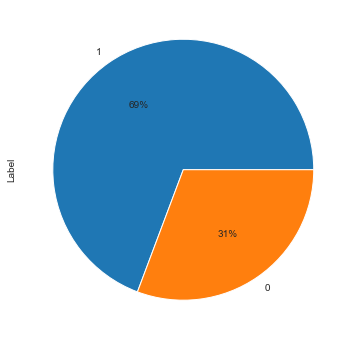

In [188]:
# plot pie chart 
df.Label.value_counts().plot(kind='pie', autopct='%1.0f%%', figsize=(6, 6))

<AxesSubplot:>

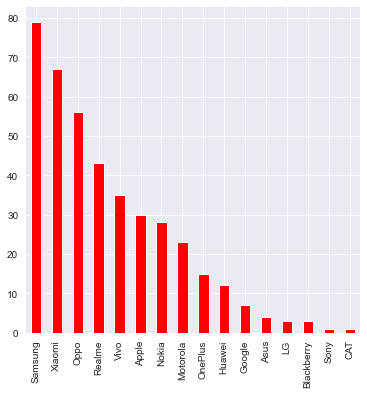

In [160]:
df['Brand'].value_counts().plot(kind='bar',figsize=(6, 6), color = 'Red')

Bivariate

Text(0.5, 1.0, '[Price vs Brand] by Screen Size')

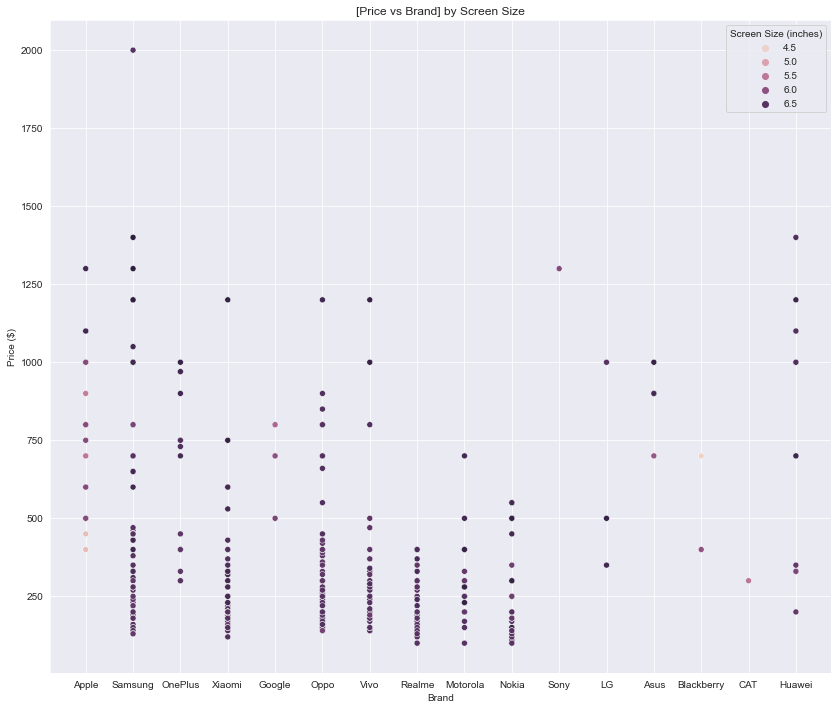

In [161]:
plt.figure(figsize=(14,12))
sns.set_style("darkgrid")
sns.scatterplot(data=df,x="Brand",y="Price ($)",hue="Screen Size (inches)")
plt.title("[Price vs Brand] by Screen Size")

<AxesSubplot:xlabel='Brand', ylabel='Price ($)'>

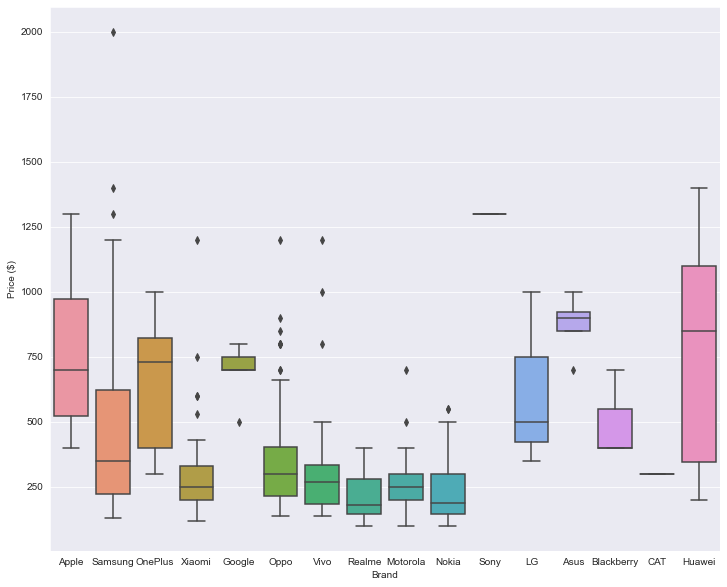

In [190]:
#check? Outlier using a boxplot
plt.figure(figsize=(12,10))
sns.boxplot(x="Brand", y='Price ($)', data=df)

Multivariate

<AxesSubplot:>

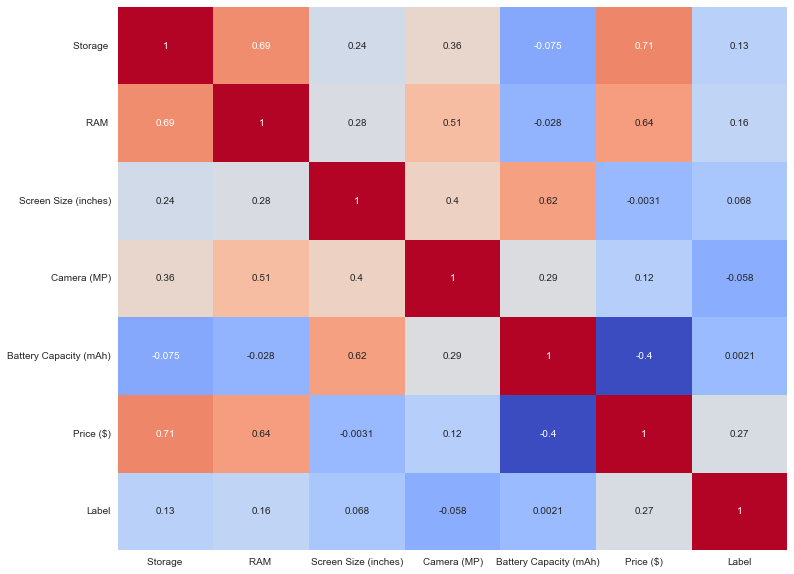

In [162]:
plt.figure(figsize=(12,10))

corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, cbar=False)

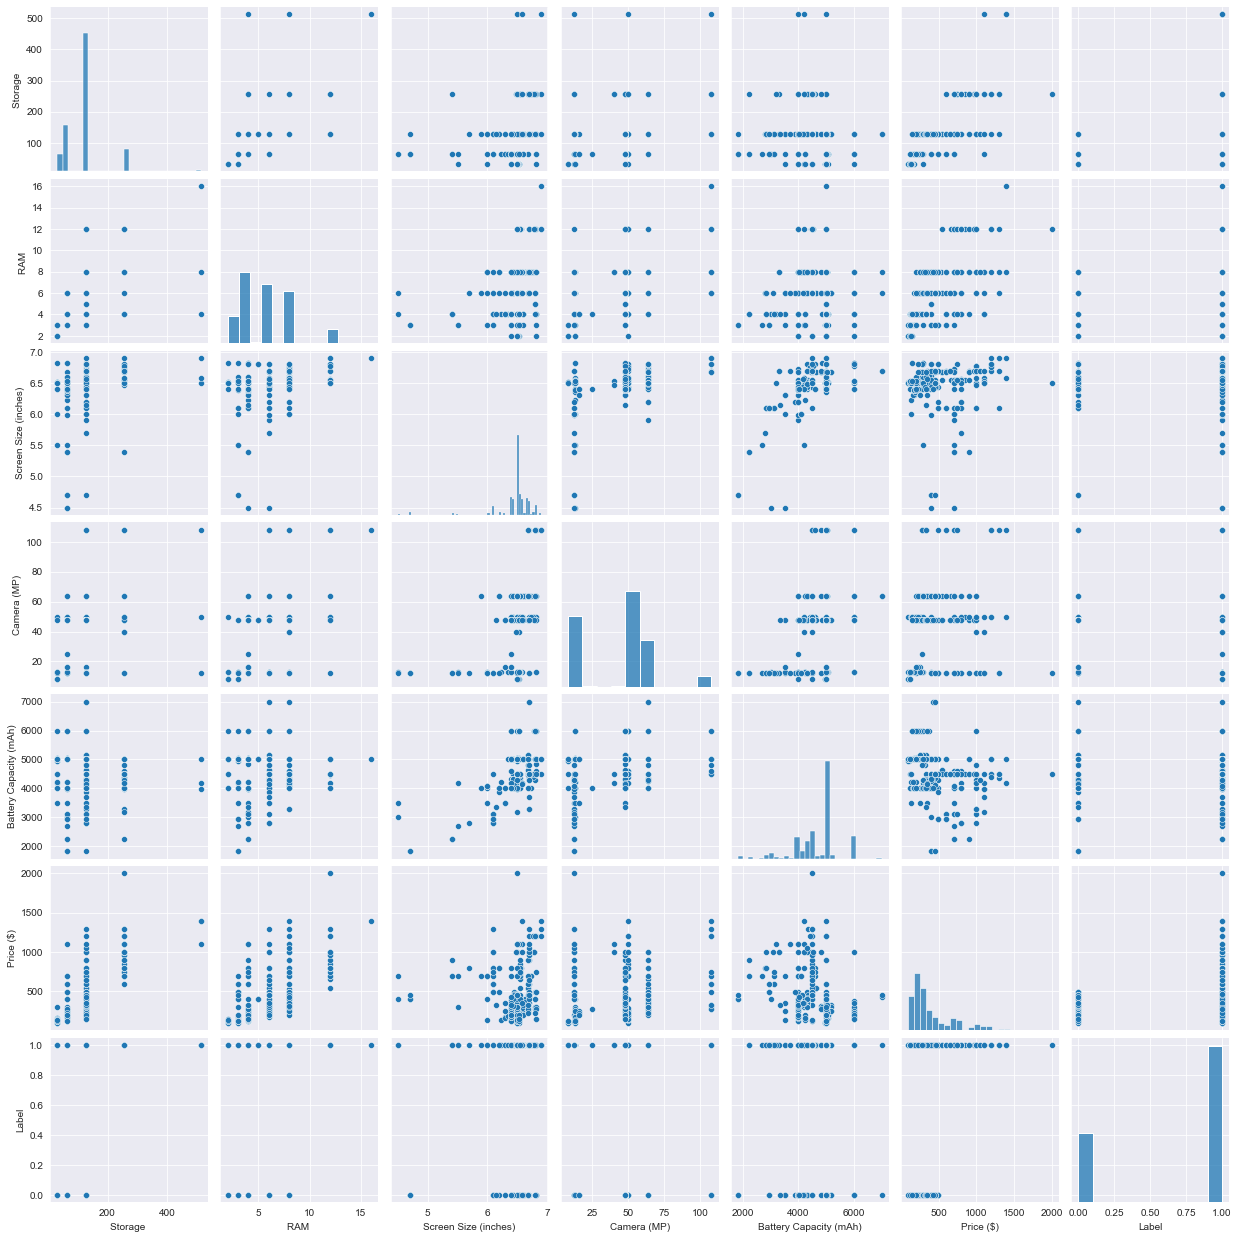

In [164]:
Lpairplot=sns.pairplot(df)

In [165]:
data = pd.get_dummies(df,columns=['Brand'],drop_first=True)
data.head(2)

,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($),Label,Brand_Asus,Brand_Blackberry,...,Brand_LG,Brand_Motorola,Brand_Nokia,Brand_OnePlus,Brand_Oppo,Brand_Realme,Brand_Samsung,Brand_Sony,Brand_Vivo,Brand_Xiaomi
0,iPhone 13 Pro,128.0,6.0,6.1,12.0,3095,999.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Galaxy S21 Ultra,256.0,12.0,6.8,108.0,5000,1199.0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


In [166]:
df.Model.nunique()

239

In [167]:
x = data.drop(["Price ($)",'Label','Model'],axis=1)
y = data["Price ($)"]

In [168]:
x

,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Brand_Asus,Brand_Blackberry,Brand_CAT,Brand_Google,Brand_Huawei,Brand_LG,Brand_Motorola,Brand_Nokia,Brand_OnePlus,Brand_Oppo,Brand_Realme,Brand_Samsung,Brand_Sony,Brand_Vivo,Brand_Xiaomi
0,128.0,6.0,6.10,12.0,3095,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,256.0,12.0,6.80,108.0,5000,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,128.0,8.0,6.70,48.0,4500,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,128.0,6.0,6.67,64.0,5020,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,128.0,8.0,6.40,50.0,4614,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,128.0,8.0,6.70,12.0,4300,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
403,128.0,6.0,6.57,48.0,4160,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
404,128.0,6.0,6.70,12.0,3687,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
405,128.0,8.0,6.40,48.0,4025,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [169]:
y

0       999.0
1      1199.0
2       899.0
3       279.0
4       799.0
        ...  
402    1049.0
403     349.0
404    1099.0
405     429.0
406     649.0
Name: Price ($), Length: 407, dtype: float64

In [170]:
#scaling dataset
#importing the standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_x = scaler.fit_transform(x)

#### Linear Regression

In [171]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(scaled_x, y, test_size=0.1, random_state=1)

In [172]:
#import regression models from sckitlearn
from sklearn.linear_model import LinearRegression #(ols)
from sklearn.metrics import mean_squared_error, r2_score

In [173]:
#instantiating and fitting model on trainign data set
ols_model = LinearRegression()
ols_model.fit(X_train,y_train)

LinearRegression()

In [174]:
pred = ols_model.predict(X_test)

In [175]:
mse = mean_squared_error(y_test,pred)
print(f"MSE SCORE: {mse}")

r2 = r2_score(y_test,pred)
print(f"R2 SCORE: {r2}")

rmse = np.sqrt(mse)
print(f"RMSE SCORE: {rmse}")


MSE SCORE: 8069.384524387115
R2 SCORE: 0.9195627309824655
RMSE SCORE: 89.82975300192645


In [176]:
df_results = pd.DataFrame({'Actual':y_test,'Predicted values': pred})
df_results['loss/residuals'] = df_results['Actual'] - df_results['Predicted values']
df_results

,Actual,Predicted values,loss/residuals
200,219.0,320.519772,-101.519772
45,699.0,586.334053,112.665947
340,249.0,373.146784,-124.146784
3,279.0,336.632122,-57.632122
115,799.0,890.739650,-91.739650
285,129.0,43.922561,85.077439
80,699.0,704.867474,-5.867474
400,329.0,315.949129,13.050871
356,179.0,342.810153,-163.810153
351,999.0,936.247455,62.752545


#### Decision Tree Regressor

In [177]:
from sklearn.tree import DecisionTreeRegressor

In [178]:
dectreesor = DecisionTreeRegressor()
dectreesor.fit(X_train,y_train)

DecisionTreeRegressor()

In [179]:
pred = dectreesor.predict(X_test)

In [180]:
mse = mean_squared_error(y_test,pred)
print(f"MSE SCORE: {mse}")

r2 = r2_score(y_test,pred)
print(f"R2 SCORE: {r2}")

rmse = np.sqrt(mse)
print(f"RMSE SCORE: {rmse}")

MSE SCORE: 2377.941903794038
R2 SCORE: 0.9762961906146025
RMSE SCORE: 48.76414567891083


#### Random Forest Regressor


In [201]:
from sklearn.ensemble import RandomForestRegressor

In [202]:
forestregsor = RandomForestRegressor()
forestregsor.fit(X_train,y_train)

RandomForestRegressor()

In [203]:
pred = forestregsor.predict(X_test)

In [204]:
mse = mean_squared_error(y_test,pred)
print(f"MSE SCORE: {mse}")

r2 = r2_score(y_test,pred)
print(f"R2 SCORE: {r2}")

rmse = np.sqrt(mse)
print(f"RMSE SCORE: {rmse}")

MSE SCORE: 0.22470969201051683
R2 SCORE: -0.14465755233235988
RMSE SCORE: 0.47403553876319954


### CLASSIFICATION 

Decision Tree

In [181]:
from sklearn.model_selection import train_test_split#spliting the dataset
from sklearn.tree import DecisionTreeClassifier#Decision tree algorithm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score#metrics

In [182]:
X = data.drop(["Price ($)",'Label','Model'],axis=1)
y = data["Label"]

In [183]:
# Splitting the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Training the Decision Tree Classifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Making predictions on the test set
y_pred = clf.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy: %.2f' % accuracy)
print('Precision: %.2f' % precision)
print('recall: %.2f' % recall)
print('f1: %.2f' % f1)

Accuracy: 0.66
Precision: 0.81
recall: 0.70
f1: 0.75


In [184]:
#model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Random Forest Model accuracy:", accuracy_score(y_test,y_pred))
print("classification report: \n", classification_report(y_test,y_pred))

Random Forest Model accuracy: 0.6585365853658537
classification report: 
               precision    recall  f1-score   support

           0       0.40      0.55      0.46        22
           1       0.81      0.70      0.75        60

    accuracy                           0.66        82
   macro avg       0.60      0.62      0.61        82
weighted avg       0.70      0.66      0.67        82



In [185]:
#from sklearn.metrics import confusion_matrix
#confusion_matrix = confusion_matrix(y_test, y_pred)
#print(confusion_matrix)

#### Logistic Regression

In [186]:
from sklearn.linear_model import LogisticRegression
logcla = LogisticRegression()

In [187]:
logcla.fit(X_train, y_train)

# Making predictions on the test set
y_pred = logcla.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy: %.2f' % accuracy)
print('Precision: %.2f' % precision)
print('recall: %.2f' % recall)
print('f1: %.2f' % f1)

Accuracy: 0.68
Precision: 0.72
recall: 0.93
f1: 0.81


#### Random Forest 

In [206]:
from sklearn.ensemble import RandomForestClassifier

In [207]:
ranfoclass = RandomForestClassifier()

In [208]:
ranfoclass.fit(X_train, y_train)

# Making predictions on the test set
y_pred = ranfoclass.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy: %.2f' % accuracy)
print('Precision: %.2f' % precision)
print('recall: %.2f' % recall)
print('f1: %.2f' % f1)

Accuracy: 0.68
Precision: 0.79
recall: 0.77
f1: 0.78
